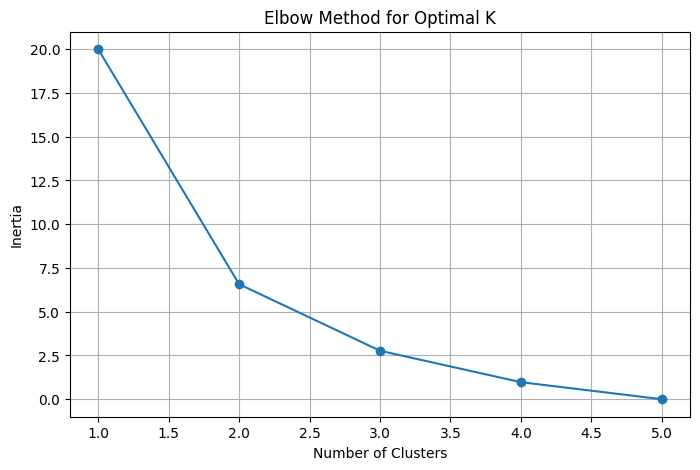

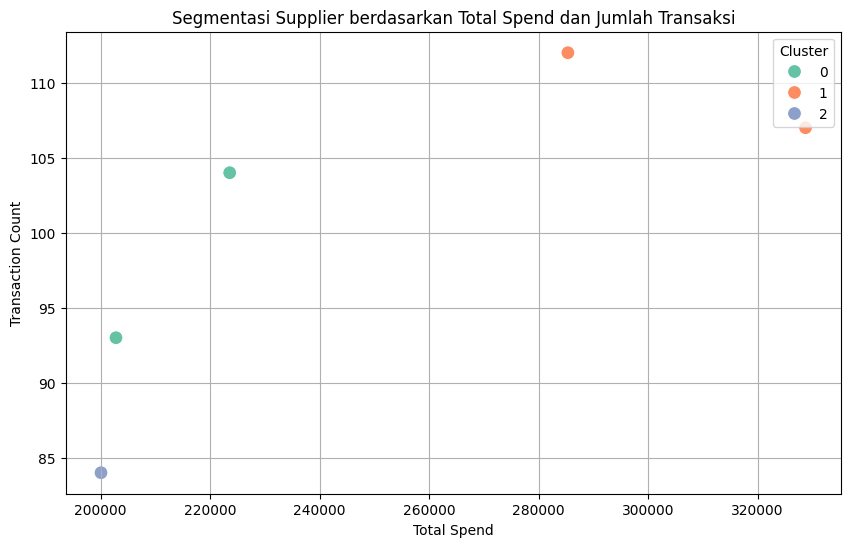

Ringkasan per Cluster:
   Cluster  TotalSpend_mean  TotalSpend_sum  AvgSpend_mean  \
0        0       213195.785       426391.57    2165.288148   
1        1       307057.660       614115.32    2810.169722   
2        2       200073.640       200073.64    2381.829048   

   TransactionCount_mean  TotalQuantity_mean  NumSuppliers_count  
0                   98.5               965.5                   2  
1                  109.5              1041.5                   2  
2                   84.0               806.0                   1  


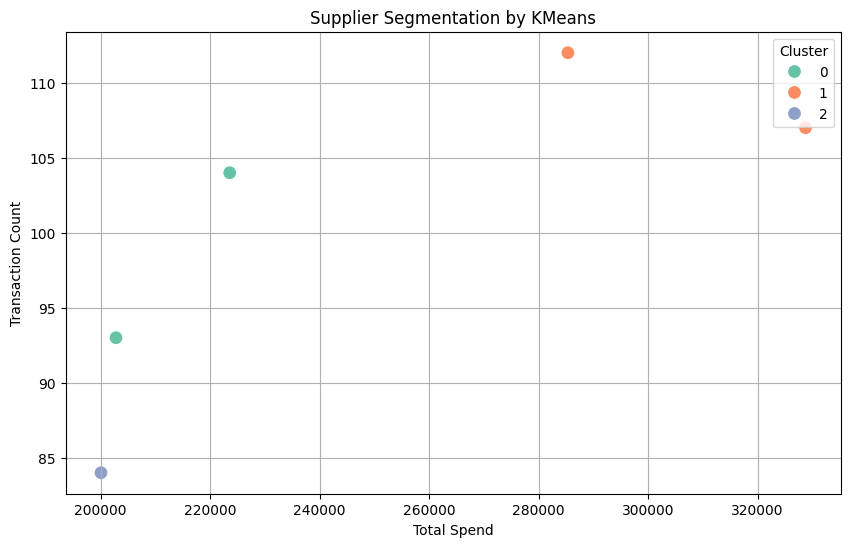

             Supplier  TotalSpend     AvgSpend  TransactionCount  \
1     FurniWorks Ltd.   202810.72  2180.760430                93   
2  OfficeSupplies Co.   223580.85  2149.815865               104   
3   QuickDeliver Ltd.   285353.59  2547.799911               112   
4       TechMart Inc.   328761.73  3072.539533               107   
0     CloudSoft Corp.   200073.64  2381.829048                84   

   TotalQuantity  Cluster  
1           1000        0  
2            931        0  
3           1060        1  
4           1023        1  
0            806        2  


In [5]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ===  BACA DATA ===
df = pd.read_csv('/content/spend_analysis_dataset.csv')  # ganti path jika perlu

# ===  AGREGASI DATA SUPPLIER ===
supplier_df = df.groupby('Supplier').agg({
    'TotalCost': ['sum', 'mean', 'count'],
    'Quantity': 'sum'
}).reset_index()

# Rename kolom multiindex
supplier_df.columns = ['Supplier', 'TotalSpend', 'AvgSpend', 'TransactionCount', 'TotalQuantity']

# ===  PRA-PROSES: NORMALISASI ===
X = supplier_df[['TotalSpend', 'AvgSpend', 'TransactionCount', 'TotalQuantity']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Hitung jumlah maksimum klaster yang mungkin (tidak lebih dari jumlah supplier)
max_k = min(10, len(supplier_df))  # misalnya 5 supplier → max_k = 5

inertia = []
for k in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_k + 1), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# Gunakan K=3 jika jumlah supplier mencukupi
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
supplier_df['Cluster'] = kmeans.fit_predict(X_scaled)



# ===  KMEANS CLUSTERING (misal K=3, sesuaikan jika perlu) ===
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
supplier_df['Cluster'] = kmeans.fit_predict(X_scaled)

# === VISUALISASI CLUSTER DENGAN SCATTERPLOT ===
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='TotalSpend',
    y='TransactionCount',
    hue='Cluster',
    data=supplier_df,
    palette='Set2',
    s=100
)
plt.title('Segmentasi Supplier berdasarkan Total Spend dan Jumlah Transaksi')
plt.xlabel('Total Spend')
plt.ylabel('Transaction Count')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# ===  ANALISIS RINGKAS TIAP KLASTER ===
cluster_summary = supplier_df.groupby('Cluster').agg({
    'TotalSpend': ['mean', 'sum'],
    'AvgSpend': 'mean',
    'TransactionCount': 'mean',
    'TotalQuantity': 'mean',
    'Supplier': 'count'
}).rename(columns={'Supplier': 'NumSuppliers'})

# Perbaiki nama kolom
cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary = cluster_summary.reset_index()

print("Ringkasan per Cluster:")
print(cluster_summary)


# ===  KMEANS CLUSTERING (misal K=3) ===
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
supplier_df['Cluster'] = kmeans.fit_predict(X_scaled)

# ===  VISUALISASI CLUSTER ===
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='TotalSpend',
    y='TransactionCount',
    hue='Cluster',
    data=supplier_df,
    palette='Set2',
    s=100
)
plt.title('Supplier Segmentation by KMeans')
plt.xlabel('Total Spend')
plt.ylabel('Transaction Count')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# ===  LIHAT HASIL AKHIR ===
print(supplier_df.sort_values('Cluster'))


1. Langkah pertama dalam kode ini adalah mengimpor pustaka-pustaka yang diperlukan, yaitu pandas untuk pengolahan data, KMeans dari scikit-learn untuk melakukan klasterisasi, StandardScaler untuk melakukan normalisasi data, serta matplotlib.pyplot dan seaborn untuk visualisasi data. Pustaka-pustaka ini merupakan fondasi utama dalam proses analisis data secara menyeluruh.

2. Setelah semua pustaka berhasil diimpor, proses dilanjutkan dengan membaca dataset dari file CSV yang berjudul spend_analysis_dataset.csv. Dataset ini kemudian disimpan dalam sebuah objek DataFrame bernama df untuk digunakan pada proses analisis selanjutnya.

3. Selanjutnya, dilakukan agregasi data berdasarkan kolom Supplier. Tujuannya adalah untuk menghitung total pengeluaran (TotalCost), rata-rata pengeluaran, jumlah transaksi, dan total kuantitas barang yang dibeli oleh masing-masing supplier. Hasil dari agregasi ini disimpan dalam sebuah DataFrame baru bernama supplier_df. Kemudian, nama-nama kolom hasil agregasi yang semula berbentuk multi-indeks diubah menjadi lebih deskriptif dan mudah dibaca, seperti TotalSpend, AvgSpend, TransactionCount, dan TotalQuantity.

4. Langkah berikutnya adalah melakukan pra-pemrosesan data dengan cara normalisasi. Normalisasi dilakukan agar setiap variabel memiliki skala yang sama, sehingga tidak ada fitur yang mendominasi hasil klasterisasi karena perbedaan satuan atau besaran nilainya. Proses ini dilakukan menggunakan StandardScaler, di mana setiap fitur akan diubah sehingga memiliki nilai rata-rata nol dan standar deviasi satu.

5. Setelah data dinormalisasi, dilakukan penentuan jumlah klaster yang optimal menggunakan metode Elbow. Dalam metode ini, model KMeans dijalankan dengan berbagai jumlah klaster, mulai dari 1 hingga batas maksimum tertentu (dalam kasus ini hingga 10 atau sesuai dengan jumlah supplier yang tersedia). Setiap model menghasilkan nilai inertia, yaitu ukuran seberapa kompak klaster yang terbentuk. Hasil inertia kemudian divisualisasikan dalam bentuk grafik untuk memudahkan identifikasi jumlah klaster terbaik berdasarkan titik siku (elbow) pada kurva.

6. Setelah jumlah klaster ditentukan (misalnya sebanyak 3 klaster), dilakukan pelatihan model KMeans dan hasil prediksi klaster dimasukkan ke dalam kolom baru pada supplier_df dengan nama Cluster.

7. Langkah selanjutnya adalah melakukan visualisasi hasil klasterisasi menggunakan diagram sebar (scatter plot). Dalam visualisasi ini, dua dimensi data yang digunakan adalah TotalSpend dan TransactionCount, di mana setiap titik mewakili satu supplier, dan warna titik menunjukkan klaster tempat supplier tersebut dikelompokkan. Hal ini memungkinkan pengguna untuk melihat pola atau segmentasi secara visual.

8. Analisis kemudian dilanjutkan dengan merangkum informasi dari masing-masing klaster. Setiap klaster dianalisis berdasarkan nilai rata-rata pengeluaran total, rata-rata pengeluaran per transaksi, rata-rata jumlah transaksi, jumlah kuantitas barang, serta jumlah supplier dalam setiap klaster. Hasil analisis ini disusun dalam bentuk tabel ringkasan agar lebih mudah untuk ditafsirkan.

9. Terakhir, hasil akhir berupa daftar supplier yang telah dikelompokkan berdasarkan klaster ditampilkan. Informasi ini dapat digunakan untuk pengambilan keputusan strategis seperti negosiasi harga, prioritas pengadaan, atau pengelolaan hubungan dengan supplier.